In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [2]:
def plot_utility_evolution(csv_paths, labels):

    """
    Creates a line plot comparing the Game Value (Utility) over the epochs.
    """
    
    plt.figure(figsize=(10, 6))
    
    colors = ['#1f77b4', '#d62728'] 
    
    for path, label, color in zip(csv_paths, labels, colors):
        if not os.path.exists(path):
            print(f"⚠️ Cannot find file: {path}")
            continue
        
        # Read the CSV file
        df = pd.read_csv(path, sep=';')
        df.columns = df.columns.str.strip()
        
        # Filter to keep only the first equilibrium of each epoch (normally the only one)
        df_eq = df[df['Equilibrium_Num'] == 1]
        
        plt.plot(df_eq['Epoch'], df_eq['Delta_Value'], marker='o', linewidth=2, 
                 color=color, label=f'Epsilon {label}')
        
    plt.title('Evolution of Accuracy Drop (Game Value) per Epoch', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy Drop (%)', fontsize=12)
    plt.xticks(range(1, 21)) 
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

In [3]:
def plot_strategies_heatmap(csv_path, epsilon_label):

    """
    Creates two Heatmaps (Attacker and Defender) to visualize how the probabilities
    of choosing each network change over the epochs.
    """
        
    # Read the CSV file
    df = pd.read_csv(csv_path, sep=';')
    df.columns = df.columns.str.strip()
    
    df_eq = df[df['Equilibrium_Num'] == 1]
    
    cols_A = [f'A{i}' for i in range(1, 11)]
    cols_D = [f'D{i}' for i in range(1, 11)]
    
    data_A = df_eq[cols_A].values.T
    data_D = df_eq[cols_D].values.T
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    
    # Attacker's heatmap (Red tones)
    sns.heatmap(data_A, cmap="Reds", ax=axes[0], vmin=0, vmax=1, 
                xticklabels=df_eq['Epoch'], yticklabels=cols_A, cbar_kws={'label': 'Probability'})
    axes[0].invert_yaxis()
    axes[0].set_title(f"Evolution of Attacker Strategies (Epsilon = {epsilon_label})", fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Generator (Attacker)')
    
    # Defender's heatmap (Blue tones)
    sns.heatmap(data_D, cmap="Blues", ax=axes[1], vmin=0, vmax=1, 
                xticklabels=df_eq['Epoch'], yticklabels=cols_D, cbar_kws={'label': 'Probability'})
    axes[1].invert_yaxis()
    axes[1].set_title(f"Evolution of Defender Strategies (Epsilon = {epsilon_label})", fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Classifier (Defender)')
    
    plt.tight_layout()
    plt.show()

Generating Utility Function Plot...


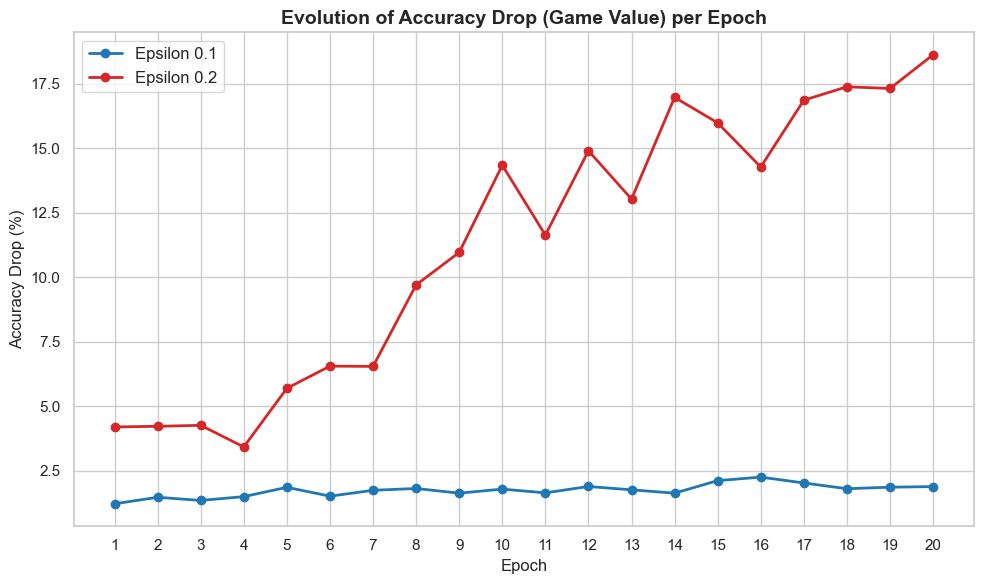


Generating Heatmaps for Epsilon 0.1...


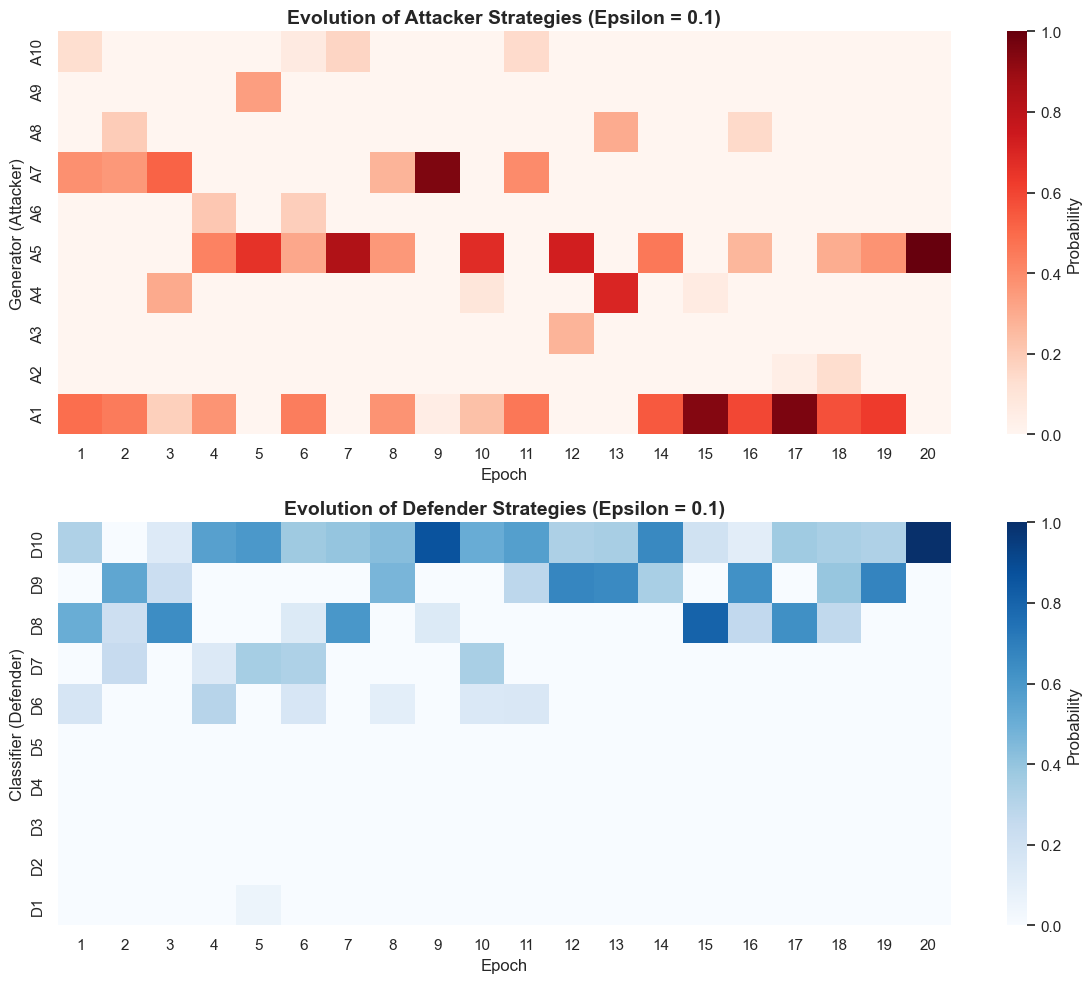


Generating Heatmaps for Epsilon 0.2...


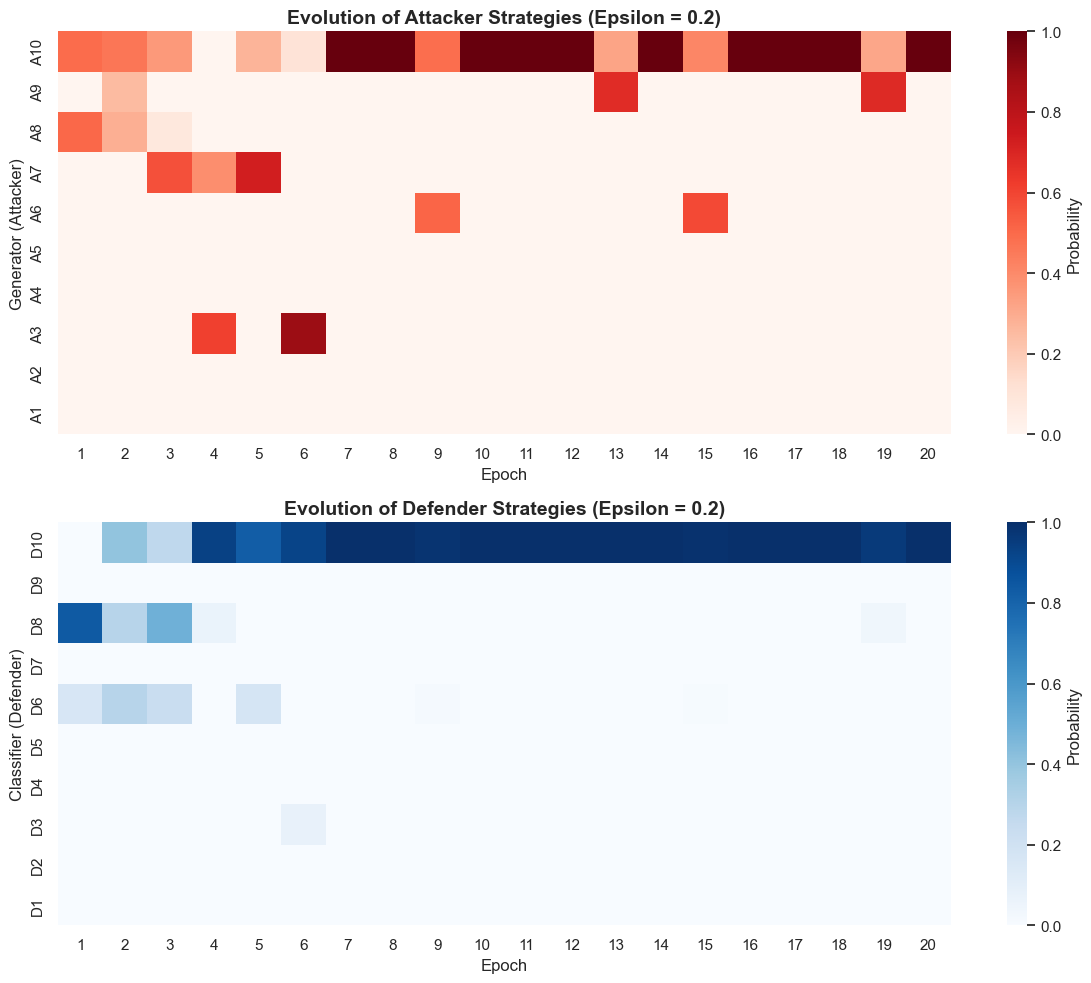

In [4]:
# EXECUTION OF VISUALIZATIONS

file_eps_01 = '../../output/nash_equilibria/nash_10x10_eps_0.1/nash_equilibria_results.csv'
file_eps_02 = '../../output/nash_equilibria/nash_10x10_eps_0.2/nash_equilibria_results.csv'

# Utility Function Plot
print("Generating Utility Function Plot...")
plot_utility_evolution([file_eps_01, file_eps_02], ['0.1', '0.2'])

# Heatmaps for Epsilon 0.1
print("\nGenerating Heatmaps for Epsilon 0.1...")
plot_strategies_heatmap(file_eps_01, '0.1')

# Heatmaps for Epsilon 0.2
print("\nGenerating Heatmaps for Epsilon 0.2...")
plot_strategies_heatmap(file_eps_02, '0.2')